# 16 · Prototipo EmoGol

**Proyecto:** EmoGol — Trabajo de grado, Universidad del Cauca  
**Autor:** Santiago Fernando Ortega Segura · **Director:** Ph.D. Oscar Mauricio Caicedo Rendón

Extrae los comentarios de un video de YouTube publicados en sus primeras 72 horas, los clasifica con EmoGol-2B y resume la distribución de emociones, su evolución por hora y ejemplos por emoción. Esta ejecución corresponde a la final de la Copa Mundial 2026 (España 1-0 Argentina).

*Nombre durante el desarrollo: `10_Clasificador_Comentarios_Video` (algunas salidas conservan esa numeración).*

## 1. Dependencias

In [1]:
!pip install -q -U google-api-python-client transformers accelerate peft bitsandbytes "huggingface_hub<2.0" "pandas<3" matplotlib
!pip uninstall -y -q torchao

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.4/846.4 kB 39.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 75.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 80.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 2.3.3 which is incompatible.


## 2. Configuración

In [2]:
from google.colab import userdata
from huggingface_hub import login

login(token=userdata.get('HF_TOKEN'))
YOUTUBE_API_KEY = userdata.get('YOUTUBE_API_KEY')

TU_USUARIO_HF = "santiagortegasegura"
REPO_DATOS = f"{TU_USUARIO_HF}/emotion-futbol-data"
REPO_CHECKPOINTS = f"{TU_USUARIO_HF}/emotion-futbol-checkpoints"

CASO = "mundial2026_prueba"

VIDEOS = {
    "Partido 1": "6CTMAuxbkNM",
}
HORAS_ANALISIS = 72
MAX_COMENTARIOS_POR_VIDEO = 3000
LIMITE_DESCARGA = 30000
SEED = 42

MODEL_ID = "google/gemma-2-2b-it"
RUTA_ADAPTADOR = "gemma2_2b/adapter_final"
MAX_LENGTH = 112
TAMANO_LOTE = 16
EMOCIONES = ['alegria', 'tristeza', 'enojo', 'miedo', 'sorpresa', 'burla', 'neutral']

print(f"Caso: {CASO} | videos: {list(VIDEOS)}")

Caso: mundial2026_prueba | videos: ['Partido 1']


## 3. Extraer comentarios

In [3]:
import re
import pandas as pd
from googleapiclient.discovery import build

youtube = build("youtube", "v3", developerKey=YOUTUBE_API_KEY)

def is_valid_comment(text):
    text = text.strip()
    if len(text) < 10:
        return False
    if re.fullmatch(r'[^\w\s]+', text):
        return False
    return True

def info_video(video_id):
    r = youtube.videos().list(part="snippet,statistics", id=video_id).execute()
    if not r["items"]:
        raise ValueError(f"No se encontró el video {video_id}")
    s = r["items"][0]["snippet"]
    return {"titulo": s["title"], "canal": s["channelTitle"], "publicado": s["publishedAt"],
            "n_comentarios_total": int(r["items"][0]["statistics"].get("commentCount", 0))}

def extraer(video_id, etiqueta, maximo):
    datos, vistos, token = [], set(), None
    while len(datos) < maximo:
        r = youtube.commentThreads().list(part="snippet", videoId=video_id, maxResults=100,
                                          pageToken=token, textFormat="plainText", order="time").execute()
        for item in r["items"]:
            if item["id"] in vistos:
                continue
            vistos.add(item["id"])
            c = item["snippet"]["topLevelComment"]["snippet"]
            texto = c["textDisplay"].strip()
            if not is_valid_comment(texto):
                continue
            datos.append({"video": etiqueta, "video_id": video_id, "comment_id": item["id"],
                          "created_at": c["publishedAt"], "likes": c["likeCount"], "text": texto})
            if len(datos) >= maximo:
                break
        token = r.get("nextPageToken")
        if not token:
            break
    return datos

partes, info = [], {}
for etiqueta, vid in VIDEOS.items():
    info[etiqueta] = info_video(vid)
    d = pd.DataFrame(extraer(vid, etiqueta, LIMITE_DESCARGA))
    n_descargados = len(d)
    d['created_at'] = pd.to_datetime(d['created_at'], utc=True)
    publicado = pd.Timestamp(info[etiqueta]['publicado'])
    horas = (d['created_at'] - publicado).dt.total_seconds() / 3600
    d = d[horas <= HORAS_ANALISIS]
    d = d[~d['text'].str.lower().str.strip().duplicated(keep='first')]
    n_ventana = len(d)
    if len(d) > MAX_COMENTARIOS_POR_VIDEO:
        d = d.sample(n=MAX_COMENTARIOS_POR_VIDEO, random_state=SEED)
    d = d.sort_values('created_at')
    info[etiqueta].update({"video_id": vid, "n_descargados": n_descargados,
                           "n_primeras_horas": n_ventana, "n_clasificados": len(d)})
    partes.append(d)
    print(f"{etiqueta}: '{info[etiqueta]['titulo']}' ({info[etiqueta]['canal']})")
    print(f"   {info[etiqueta]['n_comentarios_total']} totales -> {n_descargados} válidos descargados -> "
          f"{n_ventana} en las primeras {HORAS_ANALISIS} h (sin repetidos) -> {len(d)} a clasificar")
    if n_descargados >= LIMITE_DESCARGA:
        print("   AVISO: se llegó a LIMITE_DESCARGA; puede que falten los comentarios más antiguos.")

df = pd.concat(partes, ignore_index=True)
print(f"\nTotal a clasificar: {len(df)}")

Partido 1: 'ESPAÑA VENCIÓ A ARGENTINA Y CONSIGUIÓ SU SEGUNDA ESTRELLA | España 1-0 Argentina | RESUMEN | M104' (ESPN Fans)
   11486 totales -> 5647 válidos descargados -> 4666 en las primeras 72 h (sin repetidos) -> 3000 a clasificar

Total a clasificar: 3000


## 4. Cargar Gemma-2 2B + adaptador LoRA

In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel
from huggingface_hub import snapshot_download

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
    bnb_4bit_use_double_quant=True,
)
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

modelo_base = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb_config, device_map="auto", attn_implementation="eager")
ruta = snapshot_download(repo_id=REPO_CHECKPOINTS, repo_type="dataset", allow_patterns=[f"{RUTA_ADAPTADOR}/*"])
modelo = PeftModel.from_pretrained(modelo_base, f"{ruta}/{RUTA_ADAPTADOR}")
modelo.eval()
print("Gemma-2 2B + LoRA cargado")

config.json:   0%|          | 0.00/838 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/47.0k [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.5MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/187 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Gemma-2 2B + LoRA cargado


## 5. Clasificar y medir velocidad

In [5]:
import time
from tqdm.auto import tqdm

def prompt(texto):
    return (f"Clasifica la emoción del siguiente comentario de fútbol en una de estas categorías: "
            f"{', '.join(EMOCIONES)}.\n\nComentario: {texto}\n\nEmoción:")

TOKENS_INSTRUCCION = len(tokenizer(prompt("")).input_ids)
TOKENS_COMENTARIO = MAX_LENGTH - TOKENS_INSTRUCCION - 2

def recortar(texto):
    ids = tokenizer(texto, add_special_tokens=False).input_ids
    return texto if len(ids) <= TOKENS_COMENTARIO else tokenizer.decode(ids[:TOKENS_COMENTARIO])

print(f"Espacio para el comentario: {TOKENS_COMENTARIO} tokens")

def parsear(generado):
    limpio = generado.strip().lower().split()[0] if generado.strip() else ""
    limpio = limpio.strip(".,;:!¡¿?\"'")
    return limpio if limpio in EMOCIONES else "invalido"

textos = df['text'].tolist()
predicciones = []
torch.cuda.synchronize()
inicio = time.time()
for i in tqdm(range(0, len(textos), TAMANO_LOTE), desc="Clasificando"):
    lote = [prompt(recortar(t)) for t in textos[i:i + TAMANO_LOTE]]
    entradas = tokenizer(lote, return_tensors="pt", padding=True, truncation=True,
                         max_length=MAX_LENGTH).to(modelo.device)
    with torch.no_grad():
        salida = modelo.generate(**entradas, max_new_tokens=6, do_sample=False,
                                 pad_token_id=tokenizer.pad_token_id)
    for j in range(len(lote)):
        predicciones.append(parsear(tokenizer.decode(salida[j][entradas['input_ids'].shape[1]:],
                                                     skip_special_tokens=True)))
torch.cuda.synchronize()
segundos = time.time() - inicio

df['emocion'] = predicciones
velocidad = len(df) / segundos
print(f"{len(df)} comentarios en {segundos:.1f} s -> {velocidad:.1f} comentarios/s "
      f"({1000 * segundos / len(df):.0f} ms por comentario, lote {TAMANO_LOTE}, GPU {torch.cuda.get_device_name(0)})")
print(f"Memoria GPU pico: {torch.cuda.max_memory_allocated() / 1024**2:.0f} MB")
print(f"Respuestas fuera de las 7 emociones: {(df['emocion'] == 'invalido').mean():.1%}")

Espacio para el comentario: 70 tokens


Clasificando:   0%|          | 0/188 [00:00<?, ?it/s]

3000 comentarios en 864.2 s -> 3.5 comentarios/s (288 ms por comentario, lote 16, GPU Tesla T4)
Memoria GPU pico: 2633 MB
Respuestas fuera de las 7 emociones: 0.0%


## 6. Resumen: distribución de emociones por video

emocion    alegria  tristeza  enojo  miedo  sorpresa  burla  neutral
video                                                               
Partido 1     27.8       4.4   36.1    0.1       3.0   21.3      7.3


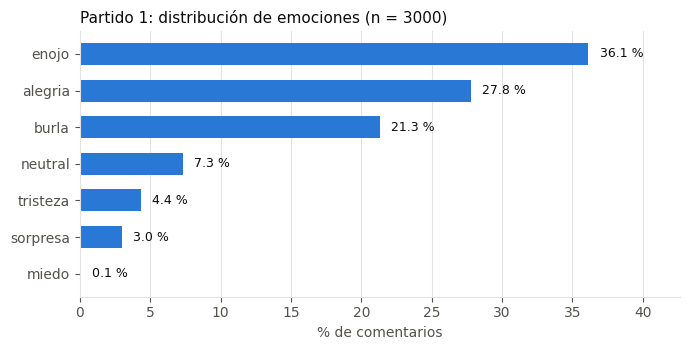

In [6]:
import matplotlib.pyplot as plt

COLORES = {'alegria': '#2a78d6', 'tristeza': '#eb6834', 'enojo': '#1baf7a', 'miedo': '#eda100',
           'sorpresa': '#e87ba4', 'burla': '#008300', 'neutral': '#4a3aa7'}
TINTA, TINTA_2, REJILLA = '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({'axes.edgecolor': REJILLA, 'axes.labelcolor': TINTA_2, 'xtick.color': TINTA_2,
                     'ytick.color': TINTA_2, 'axes.spines.top': False, 'axes.spines.right': False,
                     'font.size': 10})

validos = df[df['emocion'] != 'invalido']
tabla = (validos.groupby('video')['emocion'].value_counts(normalize=True)
         .unstack(fill_value=0).reindex(columns=EMOCIONES, fill_value=0) * 100)
print(tabla.round(1))

for video, fila in tabla.iterrows():
    fila = fila.sort_values()
    fig, ax = plt.subplots(figsize=(7, 3.6))
    barras = ax.barh(fila.index, fila.values, color='#2a78d6', height=0.6)
    for b, v in zip(barras, fila.values):
        ax.text(v + 0.8, b.get_y() + b.get_height() / 2, f"{v:.1f} %", va='center', color=TINTA, fontsize=9)
    ax.set_xlabel("% de comentarios")
    ax.set_xlim(0, max(fila.values) * 1.18)
    ax.grid(axis='x', color=REJILLA, linewidth=0.8)
    ax.set_axisbelow(True)
    n = (validos['video'] == video).sum()
    ax.set_title(f"{video}: distribución de emociones (n = {n})", loc='left', color=TINTA, fontsize=11)
    plt.tight_layout()
    nombre = f"distribucion_{re.sub(r'[^a-zA-Z0-9]+', '_', video).lower()}.png"
    fig.savefig(nombre, dpi=160)
    plt.show()

## 7. Evolución en el tiempo

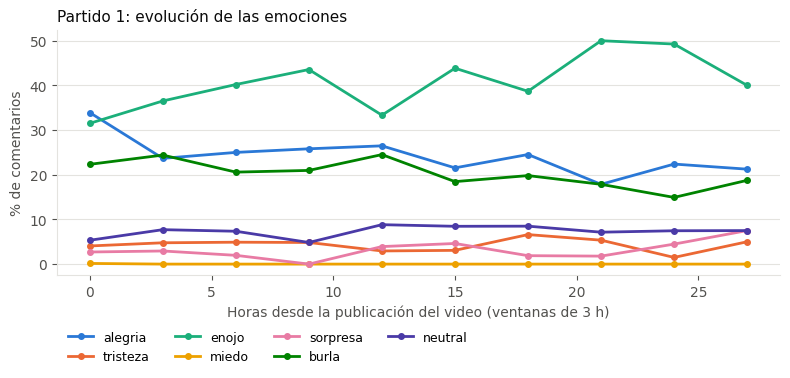

In [7]:
VENTANA_HORAS = 3
MIN_COMENTARIOS = 50
HORAS_MAX = HORAS_ANALISIS

for video in tabla.index:
    d = validos[validos['video'] == video].copy()
    publicado = pd.to_datetime(info[video]['publicado'], utc=True)
    d['horas'] = (d['created_at'] - publicado).dt.total_seconds() / 3600
    d = d[(d['horas'] >= 0) & (d['horas'] <= HORAS_MAX)]
    d['ventana'] = (d['horas'] // VENTANA_HORAS) * VENTANA_HORAS
    conteo = d.groupby('ventana').size()
    ventanas_ok = conteo[conteo >= MIN_COMENTARIOS].index
    if len(ventanas_ok) < 3:
        print(f"{video}: muy pocos comentarios por ventana para una gráfica de evolución.")
        continue
    prop = (d[d['ventana'].isin(ventanas_ok)].groupby('ventana')['emocion']
            .value_counts(normalize=True).unstack(fill_value=0).reindex(columns=EMOCIONES, fill_value=0) * 100)
    fig, ax = plt.subplots(figsize=(8, 4))
    for emo in EMOCIONES:
        ax.plot(prop.index, prop[emo], color=COLORES[emo], linewidth=2, marker='o', markersize=4, label=emo)
    ax.set_xlabel(f"Horas desde la publicación del video (ventanas de {VENTANA_HORAS} h)")
    ax.set_ylabel("% de comentarios")
    ax.grid(axis='y', color=REJILLA, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.legend(ncol=4, frameon=False, fontsize=9, loc='upper left', bbox_to_anchor=(0, -0.18))
    ax.set_title(f"{video}: evolución de las emociones", loc='left', color=TINTA, fontsize=11)
    plt.tight_layout()
    nombre = f"evolucion_{re.sub(r'[^a-zA-Z0-9]+', '_', video).lower()}.png"
    fig.savefig(nombre, dpi=160, bbox_inches='tight')
    plt.show()

## 8. Ejemplos por emoción

In [8]:
pd.set_option('display.max_colwidth', 140)
for video in tabla.index:
    print(f"\n=========== {video} ===========")
    d = validos[validos['video'] == video]
    for emo in EMOCIONES:
        top = d[d['emocion'] == emo].nlargest(3, 'likes')
        if len(top):
            print(f"\n[{emo}]")
            for _, r in top.iterrows():
                print(f"  ({r['likes']} likes) {r['text'][:140]}")


=========== Partido 1 ===========

[alegria]
  (418 likes) España salvando al mundo del fútbol
Pero jugaron solos
Viva España!!
  (376 likes) Gracias España por hacer justicia, legítimo campeón 🎉
  (317 likes) Baile total por parte de España, se comio todo el mediocampo, el mundial de rodri fue una locura, Merecido España👏

[tristeza]
  (195 likes) Infantino debe estar muy triste por su princesa. 🇦🇷
  (69 likes) Suban le el sueldo al editor no es fácil trabajar mientras lloras
  (18 likes) Bueno, duele y da bronca...pero España jugó bien y Argentina no lo supo plantear, jugó mal desde minuto 1. España es merecido campeón. Pero 

[enojo]
  (1207 likes) Otamendi fingió falta, era gol de Williams
  (810 likes) ARGENTINA EN LOS 90 MINUTOS 0 REMATES; España sin duda gano tanto como la finalissima
  (480 likes) Argentina jamás en su historia le ha ganado una final a un equipo que vista de rojo

[miedo]
  (1 likes) Ahora entiendo porque Argentina tuvo miedo de jugar la finalisima
  (0 likes)

## 9. Guardar en Hugging Face (`prototipo/<caso>/`)

In [9]:
import json, glob
from huggingface_hub import upload_file

archivo_csv = f"{CASO}_comentarios_clasificados.csv"
df.to_csv(archivo_csv, index=False)
resumen = {
    "caso": CASO, "modelo": f"{MODEL_ID} + {RUTA_ADAPTADOR}",
    "videos": {v: {**info[v], "video_id": VIDEOS[v], "n_clasificados": int((df['video'] == v).sum())} for v in VIDEOS},
    "comentarios_por_segundo": round(velocidad, 2),
    "gpu": torch.cuda.get_device_name(0),
    "pct_invalidas": round(100 * (df['emocion'] == 'invalido').mean(), 2),
    "distribucion_pct": tabla.round(2).to_dict(orient='index'),
}
with open(f"{CASO}_resumen.json", "w", encoding="utf-8") as f:
    json.dump(resumen, f, indent=2, ensure_ascii=False)

for archivo in [archivo_csv, f"{CASO}_resumen.json"] + glob.glob("distribucion_*.png") + glob.glob("evolucion_*.png"):
    upload_file(path_or_fileobj=archivo, path_in_repo=f"prototipo/{CASO}/{archivo}",
                repo_id=REPO_DATOS, repo_type="dataset")
    print(f"Subido: prototipo/{CASO}/{archivo}")

Subido: prototipo/mundial2026_prueba/mundial2026_prueba_comentarios_clasificados.csv
Subido: prototipo/mundial2026_prueba/mundial2026_prueba_resumen.json


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...istribucion_partido_1.png: 100%|##########| 44.8kB / 44.8kB            

Validating                    :           |   0%            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...t/evolucion_partido_1.png: 100%|##########| 92.5kB / 92.5kB            

Validating                    :           |   0%            

Subido: prototipo/mundial2026_prueba/evolucion_partido_1.png
